<a href="https://colab.research.google.com/github/AmalKhairalla/Online-News-Popularity/blob/main/Data_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Data

In [56]:
from google.colab import files

uploaded = files.upload()

Saving OnlineNewsPopularity.csv to OnlineNewsPopularity (2).csv


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'OnlineNewsPopularity.csv'
df = pd.read_csv(file_path)

Memory usage analysis

In [58]:
memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"Total Memory Usage: {memory_usage:.2f} MB")

Total Memory Usage: 22.18 MB


In [59]:
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

#EDA

In [60]:
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [61]:
print("Shape of dataset:", df.shape)

Shape of dataset: (39644, 61)


In [62]:
df.columns

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

In [63]:
df.dtypes

,0
url,object
timedelta,float32
n_tokens_title,float32
n_tokens_content,float32
n_unique_tokens,float32
...,...
title_subjectivity,float32
title_sentiment_polarity,float32
abs_title_subjectivity,float32
abs_title_sentiment_polarity,float32


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float32
 2    n_tokens_title                 39644 non-null  float32
 3    n_tokens_content               39644 non-null  float32
 4    n_unique_tokens                39644 non-null  float32
 5    n_non_stop_words               39644 non-null  float32
 6    n_non_stop_unique_tokens       39644 non-null  float32
 7    num_hrefs                      39644 non-null  float32
 8    num_self_hrefs                 39644 non-null  float32
 9    num_imgs                       39644 non-null  float32
 10   num_videos                     39644 non-null  float32
 11   average_token_length           39644 non-null  float32
 12   num_keywords                   

In [65]:
missing_values = df.isnull().sum()

missing_values

,0
url,0
timedelta,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
...,...
title_subjectivity,0
title_sentiment_polarity,0
abs_title_subjectivity,0
abs_title_sentiment_polarity,0


In [66]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530457,214.165253,8.00000,164.000000,339.000000,542.000000,731.000000
n_tokens_title,39644.0,10.398748,2.113835,2.00000,9.000000,10.000000,12.000000,23.000000
n_tokens_content,39644.0,546.514709,471.106293,0.00000,246.000000,409.000000,716.000000,8474.000000
n_unique_tokens,39644.0,0.548216,3.520675,0.00000,0.470870,0.539226,0.608696,701.000000
n_non_stop_words,39644.0,0.996469,5.231244,0.00000,1.000000,1.000000,1.000000,1042.000000
n_non_stop_unique_tokens,39644.0,0.689175,3.264729,0.00000,0.625739,0.690476,0.754630,650.000000
num_hrefs,39644.0,10.883690,11.331944,0.00000,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,39644.0,3.293638,3.855283,0.00000,1.000000,3.000000,4.000000,116.000000
num_imgs,39644.0,4.544143,8.308944,0.00000,1.000000,1.000000,4.000000,128.000000
num_videos,39644.0,1.249874,4.107859,0.00000,0.000000,0.000000,1.000000,91.000000


In [68]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index([' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_p

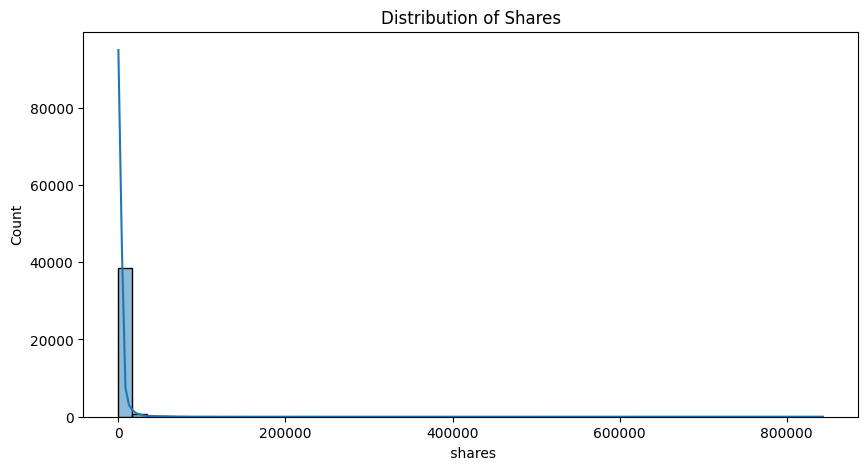

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(df[' shares'], bins=50, kde=True)

plt.title("Distribution of Shares")
plt.show()

In [70]:
print(df[' shares'].skew())

33.96388487571415


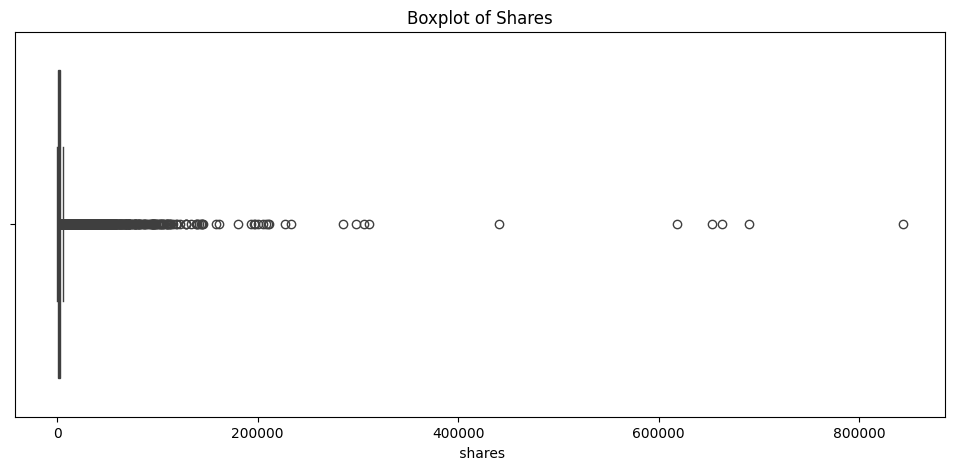

In [71]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df[' shares'])

plt.title("Boxplot of Shares")

plt.show()

In [72]:
Q1 = df[' shares'].quantile(0.25)
Q3 = df[' shares'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[' shares'] < lower_bound) |
    (df[' shares'] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 4541


##Density plots

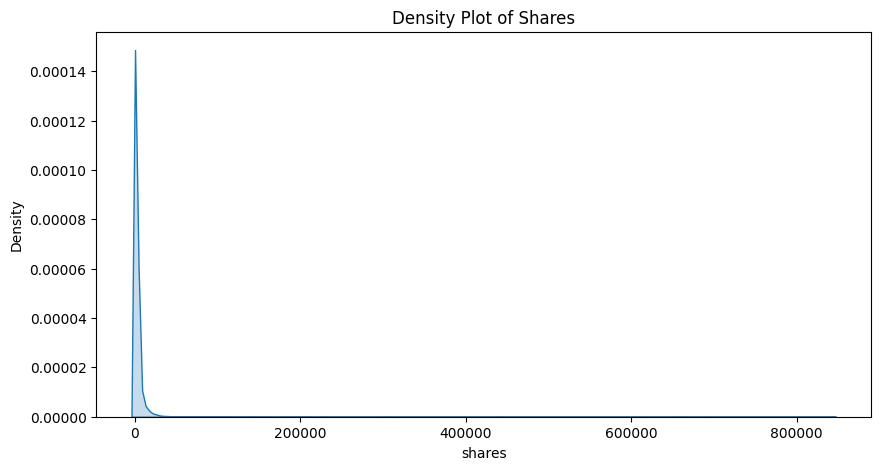

In [78]:
plt.figure(figsize=(10,5))

sns.kdeplot(df['shares'], fill=True)

plt.title("Density Plot of Shares")

plt.show()

##Scatter plots

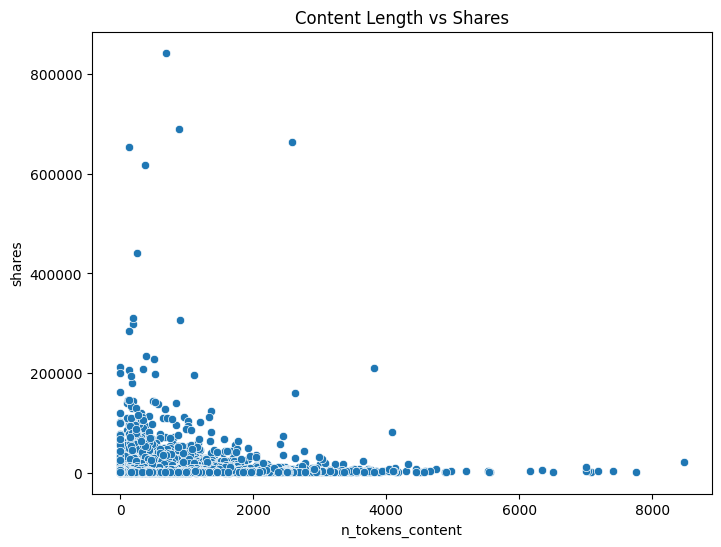

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['n_tokens_content'],
    y=df['shares']
)

plt.title("Content Length vs Shares")

plt.show()

##Pairwise relationships

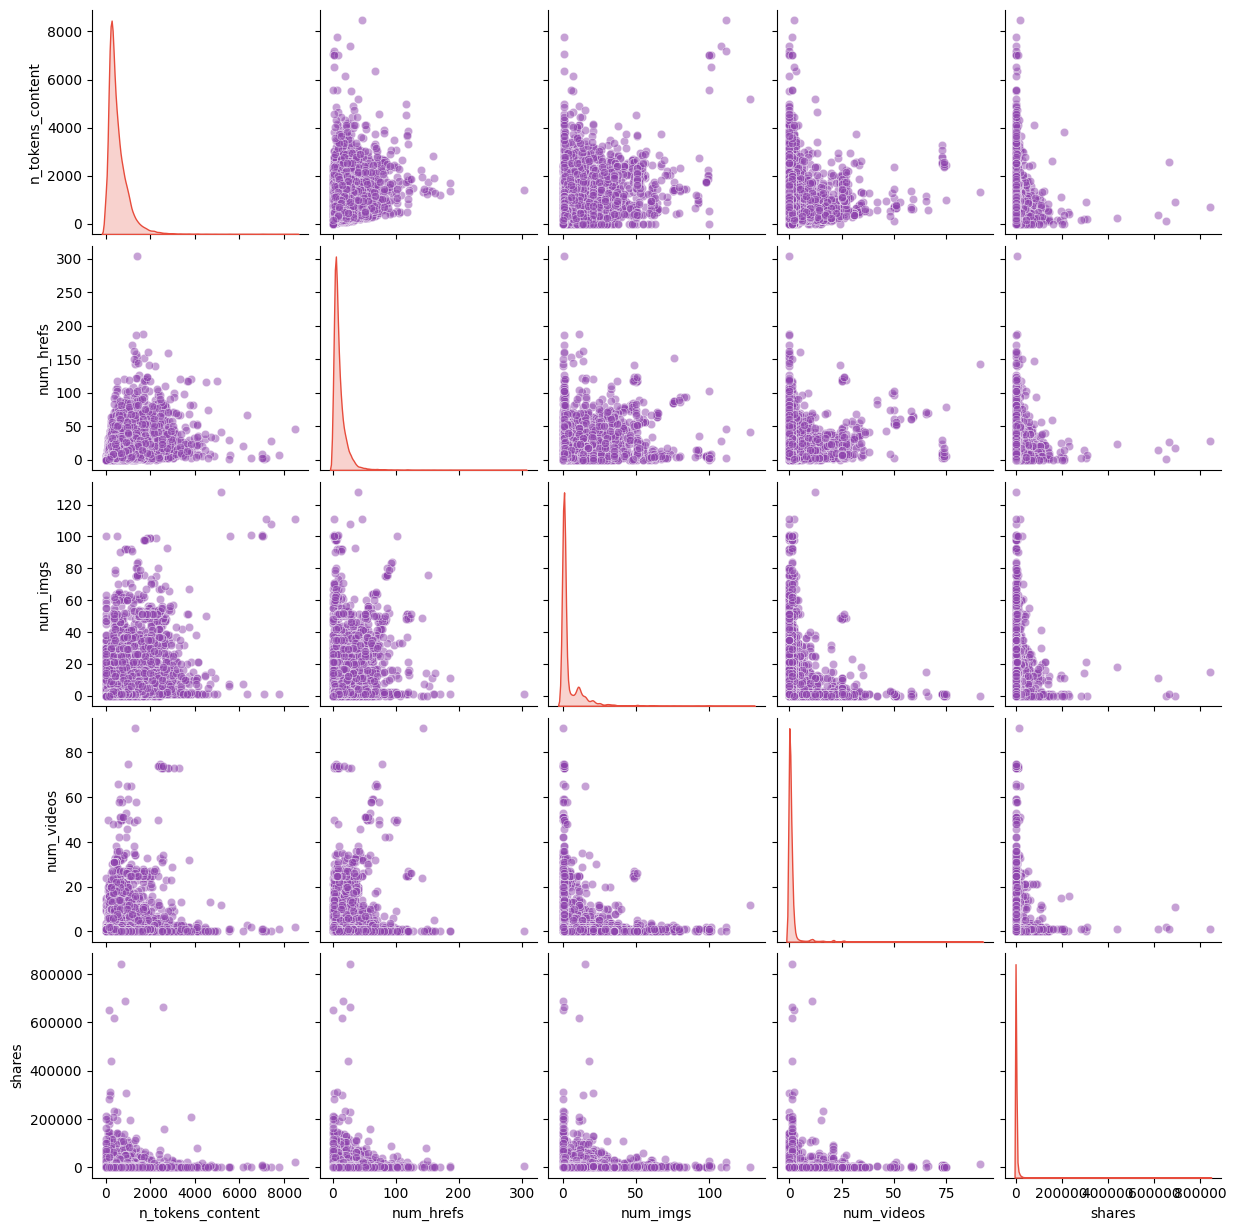

In [87]:
selected_features = [
    'n_tokens_content',
    'num_hrefs',
    'num_imgs',
    'num_videos',
    'shares'
]

sns.pairplot(
    df[selected_features],

    diag_kind='kde',

    plot_kws={
        'color': '#8e44ad',
        'alpha': 0.5
    },

    diag_kws={
        'color': '#e74c3c',
        'fill': True
    }
)

plt.show()

##Correlation heatmaps

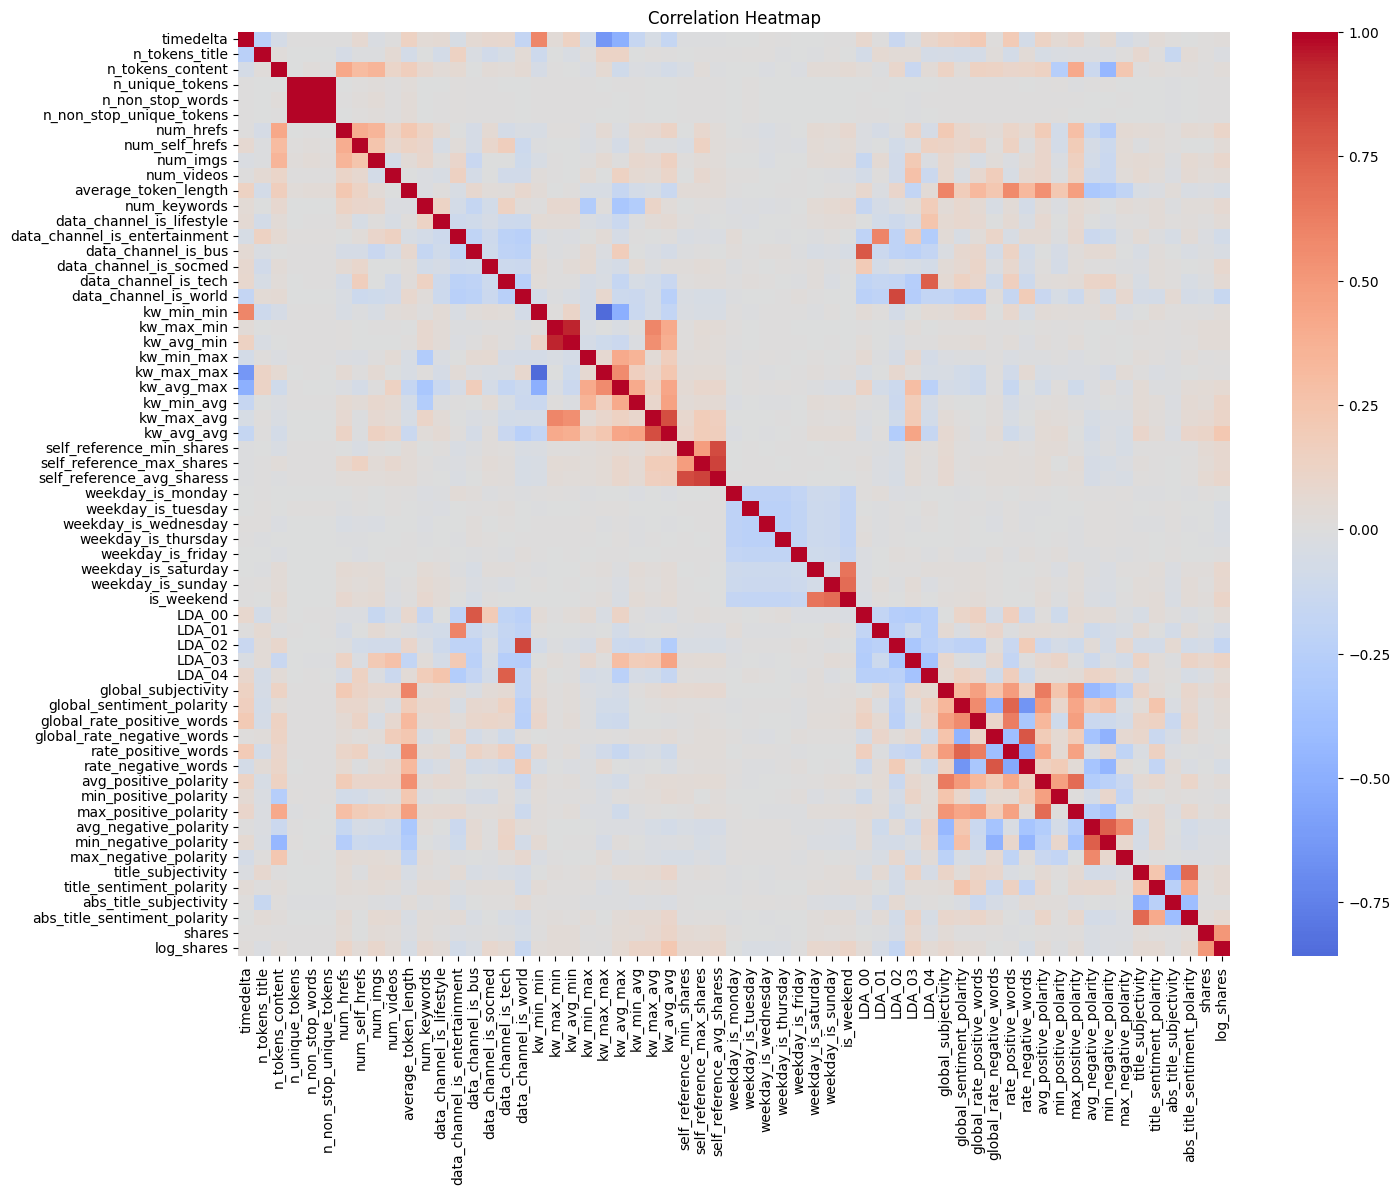

In [81]:
plt.figure(figsize=(16,12))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

Topic/category analysis

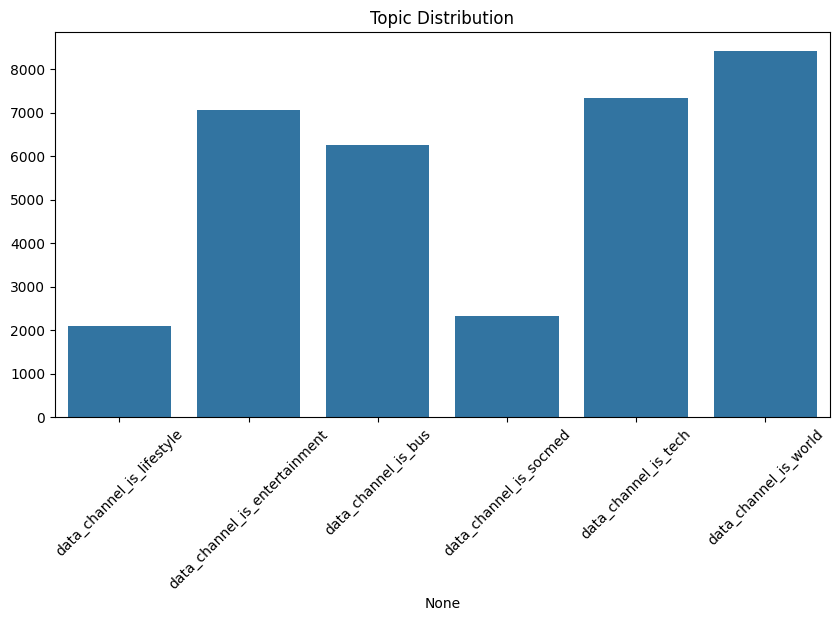

In [82]:
topic_cols = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]

topic_counts = df[topic_cols].sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=topic_counts.index,
    y=topic_counts.values
)

plt.xticks(rotation=45)

plt.title("Topic Distribution")

plt.show()

##Day-of-week popularity trends

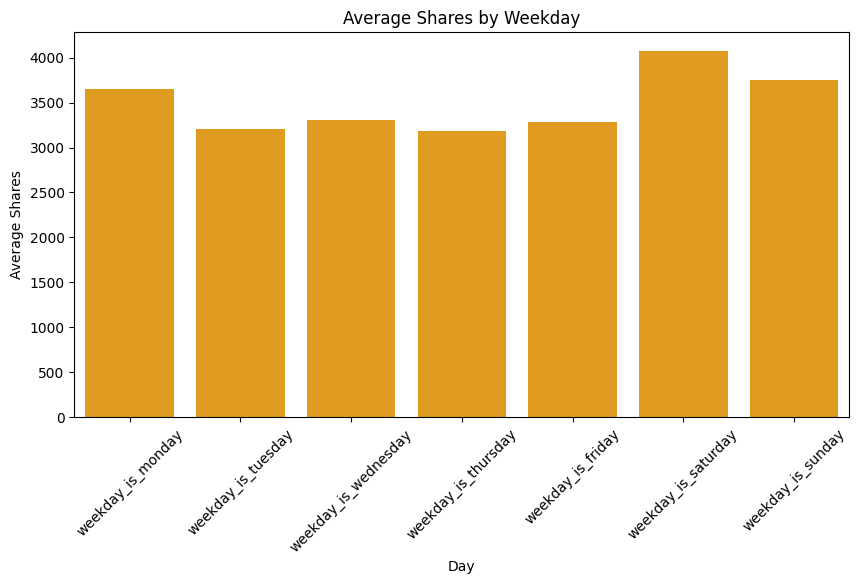

In [89]:
weekday_cols = [
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday'
]

weekday_shares = {}

for col in weekday_cols:
    weekday_shares[col] = df[df[col] == 1]['shares'].mean()

weekday_df = pd.DataFrame({
    'Day': weekday_shares.keys(),
    'Average Shares': weekday_shares.values()
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_df,
    x='Day',
    y='Average Shares',
    color='orange'   # غيري اللون هون
)

plt.xticks(rotation=45)

plt.title("Average Shares by Weekday")

plt.show()

##Sentiment vs shares analysis

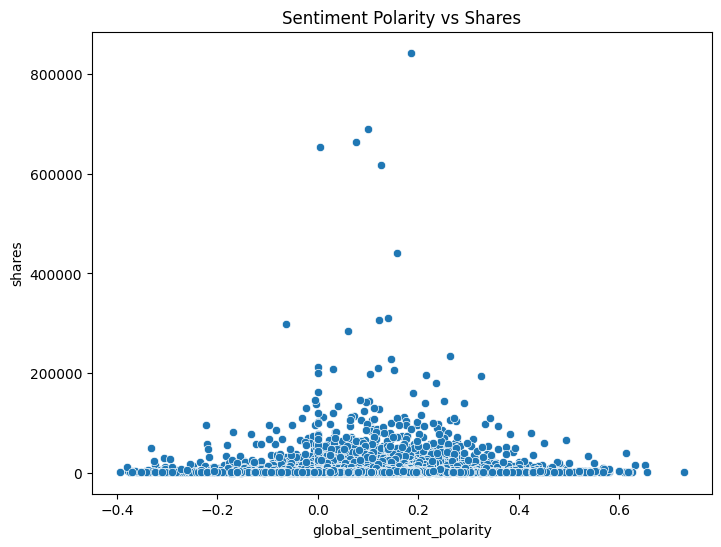

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['global_sentiment_polarity'],
    y=df['shares']
)

plt.title("Sentiment Polarity vs Shares")

plt.show()

#Preprocessing

In [73]:
df.columns = df.columns.str.strip()

In [74]:
df.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [75]:
df['log_shares'] = np.log1p(df['shares'])

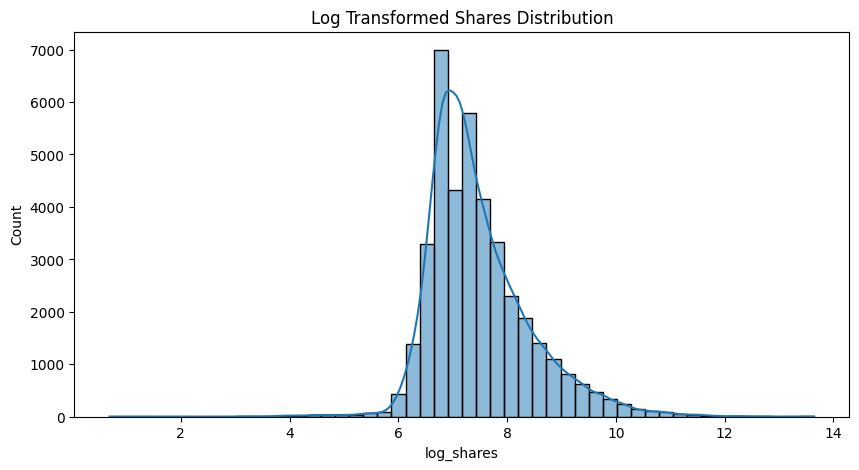

In [76]:
plt.figure(figsize=(10,5))

sns.histplot(df['log_shares'], bins=50, kde=True)

plt.title("Log Transformed Shares Distribution")

plt.show()

In [77]:
print("Before:", df['shares'].skew())

print("After:", df['log_shares'].skew())

Before: 33.96388487571415
After: 1.0264770065011177


#Feature Scaling